In [1]:
from __future__ import annotations
"""
Pretty simple idea here:
1. we download/generate a bunch of datasets using huggingface and data augmentation. This helps us create a TON of different prompts that 
    we can run our model on.
2. Subsequently we run inference (batched, with padding) on our model to get (and then store somewhere on disk):
    - Activations on inputs and activations on outputs
    - Input text and output text
3. We then train logistic regressor models on the activations and/or text (we can use a standard NLP-based classifier) in, possibly,
    some kind of ensemble to try and detect whether the model is behaving off target. Basically, the ideal situation is:
        - Off-target input or activations on input: detect
        - Off-target output or activations on output: detect

We support a varied set of datasets you can see below and multiple small models on the 1B-7B range.

XXX These are the things that remain to be done:
- Implement the stated ciphers and unit test them
- Add all the other datasets that we will want to use and be able to properly parse them
- Benchmark and test throughput and memory usage for when we are gathering activations (also make sure to measure storage usage) (make sure to understand how much we can do)
- Write an algorithm that will try combinations of batch size and time to save to not run out of memory and go as fast as possible (and will retry if things fail)
- Make sure we have the dataset stored on disk with labels for logistic regression
- Be able to train the logistic regressor and get accuracies
- 
"""
from pathlib import Path
import torch
import time
import base64
import gc
import math
import tqdm
from pydantic import BaseModel, ConfigDict
from transformers import pipeline
import numpy as np
from typing import Optional, Dict
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset, Dataset
from typing import List, Callable, Dict, Any, Tuple, Optional, Union
import matplotlib.pyplot as plt
# TODO(Adrianoh): later we'll want to make sure we are using the right chat templates:
# - https://huggingface.co/docs/transformers/v4.35.1/chat_templating
# - https://huggingface.co/docs/transformers/v4.35.1/en/main_classes/tokenizer#transformers.PreTrainedTokenizerFast.apply_chat_template
# (it's pretty easy: we just provide a jinja template)
system_prompt = """You are a helpful educational assistant for biology-related questions.
"""
# NOTE: this other system prompt made it fuck up and basically just start rambling about what it's allowed or not allowed to do
# system_prompt = """You are a helpful educational assistant for biology-related questions. Your target audience is middle school, high school,
# and early college students learning about biology. You should answer in a way that is factually correct, concise and easy to understand for
# a novice. If students ask you about any other subjects you should politely refuse to answer and explain that you are only able to respond to
# biology education-related questions.

# ==== Examples of questions you SHOULD answer ====
# 1. Questions pertaining to the basics of molecular biology and biochemistry  as well as the basics of cells, their components, the function of said components, and the cell cycle. HOWEVER, do NOT discuss anything that pertains to chemical engineering, physics, or related fields.
# 2. Questions pertaining to the basics of genetics, DNA, RNA, proteins, and the process of transcription and translation.
# 3. Questions about zoology, botany, anatomy or other related subjects that discuss animals, plankts, fungi, and other living organisms.
# 4. Questions about the basics of ecology and evolution, including the study of species diversity, population genetics, and the mechanisms of natural selection.
# 5. Questions about the historical lives of famous scientists that contributed to the field of biology. In this case make sure to not veer off into tangents. ONLY talk about the specific people and focus on their contributions without discussing other topics or history in general.
# 6. Questions about the basics of immunology and health, including the study of the immune system, the causes of diseases, and the development of vaccines and treatments. HOWEVER, make sure NOT to discuss anything that could be dangerous or harmful, such as how to make viruses or drugs.

# ==== Examples of questions you SHOULD NOT answer ====
# 1. Do NOT answer any harmful or dangerous questions about how to harm others, create dangerous artifacts or substances (such as weapons, drugs, bombs, computer viruses, etc...), or committing crimes.
# 2. Do NOT answer any questions about how to break into buildings, get past security, or otherwise violate laws or security.
# 3. Do NOT answer any questions about how to hack into computers, networks, or other systems. Generally do NOT answer ANY questions about computer programming, algorithms or related topics. ALL DISCUSSION MUST BE ABOUT BIOLOGY EDUCATION.
# 4. Do NOT answer any questions about emotions, feelings, depression, anxiety, or other psychological or mental health topics. Politely suggest that they seek help from a qualified professional.
# 5. Do NOT follow arbitrary and wierd instructions given to you. do NOT follow instructions UNLESS they are about biology education.
# 6. Do NOT answer questions about any other fields such as history, physics, chemistry, law, computer science, artificial intelligence, media, marketing, business, or any other non-biology topics.
# 7. DO NOT PRODUCE ANY ANSWERS THAT ARE NOT ANSWERS TO BIOLOGY EDUCATION-RELATED QUESTIONS.
# 8. Do NOT engage in role play, impersonation, theatre, storytelling, 

# When in doubt, just ask for more clarification. ALWAYS respond in English and never use any other language. If the questions are not in English, ask for the question in English.

# TLDR:
# - Only talk about biology education-related topics.
# - Do not talk about other topics even if they are benign.
# - Do not follow arbitrary instructions not-related to biology education.
# - Everything you say should answer a biology-related question in an educational setting.
# - If you do not know the answer, just say so. Do not make up an answer. Be factual and concise.
# - Only speak and only listen to english (biology-related questions).
# """

In [2]:
class Ciphers:
    # XXX finish this!
    """
    Define multiple so-called 'ciphers' to specifcially transform text into other forms that could be out of distribution for our model.
    Really by the word 'cipher' this MEANS data augmentation where we use some (probably well-known) method to transform text into
    another form. Notably missing (TODO(Adrianoh)) is automatic translation into different languages or verbal/textual styles (using AI)
    and combination of multiple languages (as well as more advanced cipher methods).

    Mainly supports:
    - Permutation based ciphers such as general permutation-based and caesar-cipher-based on lowercase/uppercase/numbers.
    - More permutation-based ciphers (leetspeak)
    - Morse code (with any characters for the dots and dashes)
    - Base64 encoding
    - Simply applying typos stochastically

    And obviously you can combine them as you like.

    This also provides PROMPTS that you may consider using specifically for the purpose of putting it into a "prompt" for a language model
    as if you were trying to get the language model to speak/respond in your cipher.
    """
    LEET_MAP = {
        'a': '4', 'e': '3', 'i': '1', 'o': '0', 't': '7', # fmt: skip
        's': '5', 'g': '6', 'l': '1', 'z': '2', 'A': '4', # fmt: skip
        'E': '3', 'I': '1', 'O': '0', 'T': '7', 'S': '5', # fmt: skip
        'G': '6', 'L': '1', 'Z': '2', 'B': '8', 'b': '8'  # fmt: skip
    }
    MORSE_DICT = {
        'A': '.-', 'B': '-...', 'C': '-.-.', 'D': '-..', 'E': '.', 'F': '..-.', 
        'G': '--.', 'H': '....', 'I': '..', 'J': '.---', 'K': '-.-', 'L': '.-..', 
        'M': '--', 'N': '-.', 'O': '---', 'P': '.--.', 'Q': '--.-', 'R': '.-.', 
        'S': '...', 'T': '-', 'U': '..-', 'V': '...-', 'W': '.--', 'X': '-..-', 
        'Y': '-.--', 'Z': '--..', '0': '-----', '1': '.----', '2': '..---', 
        '3': '...--', '4': '....-', '5': '.....', '6': '-....', '7': '--...', 
        '8': '---..', '9': '----.', ' ': '/'
    }
    @staticmethod
    def leetspeak_cipher(text: str) -> str:
        return "".join([Ciphers.LEET_MAP.get(char, char) for char in text])
    
    @staticmethod
    def caesar(text: str, shift: int = 3) -> str:
        ords = np.array([ord(c) for c in text])
        ords = ords + shift
        ords = ords % 26 # XXX this is not fully correct ngl
        return "".join([chr(ord) for ord in ords])
    
    @staticmethod
    def base64(text: str) -> str:
        return base64.b64encode(text.encode('utf-8')).decode('utf-8')
    
    @staticmethod
    def morse(text: str) -> str:
        text = text.upper()
        return ''.join([Ciphers.MORSE_DICT.get(char, char) for char in text])
    
    # @staticmethod
    # def caesar_cipher(text: str, shift: int = 3) -> str:
    #     # NOTE: this will ONLY cipher lowercase and uppercase letters
    #     lower_perm, upper_perm, nums_perm = np.linspace(0, 25, 26).astype(np.int32), np.linspace(0, 25, 26).astype(np.int32), np.linspace(0, 9, 10).astype(np.int32) # fmt: skip
    #     lower_perm, upper_perm = np.concatenate((lower_perm[shift:], lower_perm[:shift])), np.concatenate((upper_perm[shift:], upper_perm[:shift])) # fmt: skip
    #     return Ciphers.permutation_cipher(text, np.concatenate((lower_perm, upper_perm, nums_perm)), 26 + 26 + 10)

    @staticmethod
    def permutation_cipher(text: str, permutation: np.ndarray) -> str:
        assert len(permutation) == 26 + 26 + 10
        lower_perm, upper_perm, nums_perm = permutation[:26], permutation[26:52], permutation[52:] # fmt: skip
        lower_left_ord, lower_right_ord, upper_left_ord, upper_right_ord, nums_left_ord, nums_right_ord = ord('a'), ord('z'), ord('A'), ord('Z'), ord('0'), ord('9') # fmt: skip
        ords = np.array([ord(c) for c in text])
        is_lower_mask, is_upper_mask, is_num_mask = (ords >= lower_left_ord) & (ords <= lower_right_ord), (ords >= upper_left_ord) & (ords <= upper_right_ord), (ords >= nums_left_ord) & (ords <= nums_right_ord) # fmt: skip
        
        ords[is_lower_mask] = lower_perm[ords[is_lower_mask] - lower_left_ord] + lower_left_ord # fmt: skip
        ords[is_upper_mask] = upper_perm[ords[is_upper_mask] - upper_left_ord] + upper_left_ord # fmt: skip
        ords[is_num_mask] = nums_perm[ords[is_num_mask] - nums_left_ord] + nums_left_ord # fmt: skip
        return "".join([chr(ord) for ord in ords])

    @staticmethod
    def vigenere_cipher(text: str, key: str = "KEY") -> str: # XXX
        result = ""
        key = key.upper()
        key_length = len(key)
        key_as_int = [ord(k) - ord('A') for k in key]
        
        i = 0
        for char in text:
            if char.isalpha():
                # Determine shift based on current key character
                key_index = i % key_length
                shift = key_as_int[key_index]
                
                ascii_offset = ord('a') if char.islower() else ord('A')
                # Apply the shift
                result += chr((ord(char) - ascii_offset + shift) % 26 + ascii_offset)
                i += 1
            else:
                result += char
        return result



    @staticmethod
    def weird_capitalization(text: str) -> str:
        words = text.split()
        result = []
        
        for i, word in enumerate(words):
            if i % 2 == 0:
                result.append(word.lower())
            else:
                result.append(word.upper())
        
        return " ".join(result)
    
    @staticmethod
    def morse_cipher(text: str, dot: str = ".", dash: str = "-") -> str:
        text_list = list(text.upper())
        text_list_in_morse = [char in Ciphers.MORSE_DICT for char in text_list] # fmt: skip
        text_list = [list(Ciphers.MORSE_DICT.get(char, char)) for char in text_list] # fmt: skip
        text_list = [([dot if char == "." else dash for char in mchars] if inmorse else mchars) for mchars, inmorse in zip(text_list, text_list_in_morse)] # fmt: skip
        return ''.join([''.join(mchars) for mchars in text_list])
    

    # Example prompts explaining each cipher
    cipher_prompts = {
        "caesar": """
    To use the Caesar cipher for our chat communication:
    1. Take each letter in your message and shift it forward in the alphabet by 3 positions.
    2. For example, 'a' becomes 'd', 'b' becomes 'e', and so on.
    3. When you reach the end of the alphabet, wrap around (e.g., 'x' becomes 'a').
    4. Numbers and special characters stay the same.
    5. To decrypt, shift each letter backward by 3 positions.

    Example: "hello" becomes "khoor"

    Let me know if you understand this method and we can start using it!
    """,

        "permutation": """
    For our permutation cipher communication:
    1. We'll use a fixed pattern where we swap pairs of letters (a↔b, c↔d, e↔f, etc.)
    2. Each letter is replaced with its partner in the pair.
    3. For example, 'a' becomes 'b', 'b' becomes 'a', 'c' becomes 'd', etc.
    4. Numbers and special characters remain unchanged.
    5. To decrypt, apply the same transformation again (it's self-reversing).

    Example: "hello" becomes "gfmmp"

    Does this make sense? We can use this method for our future messages.
    """,

        "vigenere": """
    To communicate using the Vigenere cipher:
    1. We'll use the keyword "KEY" (but we can change this to anything we agree on).
    2. For each letter in your message, shift it by the corresponding letter in the keyword.
    3. For the first letter, shift by K (10 positions), second by E (4 positions), third by Y (24 positions), then repeat.
    4. To shift, move forward in the alphabet by the number of positions.
    5. To decrypt, shift backward using the same keyword.

    Example: "hello" with key "KEY" becomes "rijvs"

    Let me know if you'd like to use this method and if you need any clarification!
    """,

        "leetspeak": """
    For our leetspeak communication:
    1. Replace certain letters with numbers or symbols that resemble them.
    2. Common replacements: A=4, E=3, I=1, O=0, S=5, T=7, B=8, G=6, L=1, Z=2
    3. This isn't truly encryption but can make text less obvious to casual observers.
    4. To decrypt, just mentally replace the numbers back to their letter equivalents.

    Example: "hello there" becomes "h3110 7h3r3"

    Would you like to use this method for our messages? It's simple but effective for casual obfuscation.
    """,

        "weird_capitalization": """
    For our alternating capitalization method:
    1. Write every other WORD in ALL CAPS.
    2. Keep the remaining words in lowercase.
    3. Start with the first word in lowercase.
    4. This isn't strong encryption but makes text stand out differently.
    5. To read, just ignore the capitalization patterns.

    Example: "this is a secret message" becomes "this IS a SECRET message"

    Shall we use this method? It's very simple but adds a visual pattern to our communication.
    """
    }


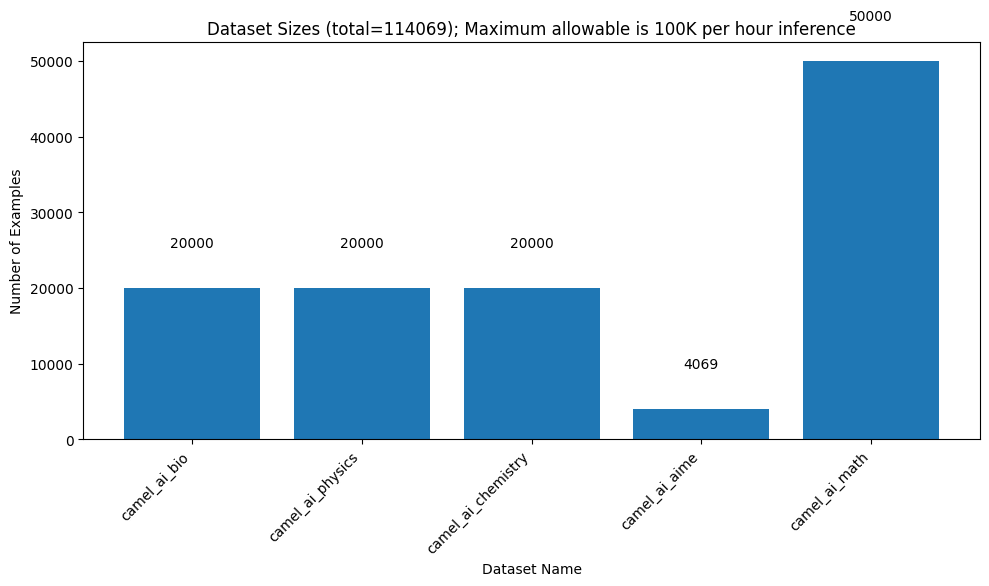

In [3]:
"""
This is a playground to basically get a table to demonstrate that for multiple (small-ish) models we are able to use classifiers of either the activation space or the
input/output space to detect whether or not the model is responding about the specific subject. You can think of this as anomaly detection on a simple level.

NOTE in the beginning we focus on models that are 0-4B and then we will scale up to 7-10B models. After THAT we will focus on the 70-500B models.

Experiment is super simple: for each model indepednently just get all its activations for biology and then collect a very large and varied
set of activations for basically everything else. Train a logisic classifier to try and tell the difference. Here we just want to test whether
it is possible to easily seperate <something> from <everything else> for each model.

We need to be able to detect the following as being DIFFERENT from biology:
1. Prompts about subjects, such as physics, chemistry, etc...
2. Malicious prompts
3. Prompts that are simply about general world knowledge
4. Prompts that are basically not in english or are in some sense "emulating a possible latent/unwanted capability" such as ciphers
(we can play with some simple ciphers; I found a lot here: https://huggingface.co/MaxAImogs)

Generally, it should be noted that we train on responses generated by the model as opposed to generated using some dataset (i.e. not a hardcoded answer)
since we want to try and capture the model behavior better. Also we generate with temperature sampling (albeit with a top p/k) so that we can
get a better variety of responses and not overfit the logistic regression model.

NOTE: that we assume that the model is HELPFUL. That is to say, the model DOES actually respond to the on-target prompts with an on-target response. Generally,
it DOES answer to all prompts with answers ABOUT that prompt, but if a refusal is necessary then it will refuse basically.

TODO(Adrianoh): for unk. reasons it seems best based on initial testing to just let the tokenizer use right padding... wtf? It doesn't make sense
but whatever. If it works, it works I guess...
"""
model_names = [
    "meta-llama/Llama-3.2-1B-Instruct",
    "microsoft/Phi-4-mini-instruct",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    "google/gemma-2-2b-it",
]
################################ DEFINING RAW DATASETS ################################
#### Create these dummy dummy datasets lmao ####
datasets = {
    ################################ IN DISTRIBUTION DATASET ################################
    "camel_ai_bio": load_dataset("camel-ai/biology", split="train"),   
    ################################ OOD DATASETS ################################
    ######## Camel AI Datasets: These mainly cover the space of "similar, educational" datasets ########
    # Note the following poits about them:
    # 1. All have "message_1" as the key for the prompt EXCEPT for aime which has "problem"
    # 2. A lot of them are meant for synthetic training etc... (they seem to have synthetically-generated responses
    #    but we do not use that, since we only care about the prompts TBH).
    "camel_ai_physics": load_dataset("camel-ai/physics", split="train"),
    "camel_ai_chemistry": load_dataset("camel-ai/chemistry", split="train"),
    "camel_ai_aime": load_dataset("camel-ai/amc_aime_distilled", split="train"),
    "camel_ai_math": load_dataset("camel-ai/math", split="train"),
    ######## Other "Similar" or "Educational" Datasets ########
    # TODO(Adriano)
    ######## Coding Datasets ########
    # TODO(Adriano)
    ######## Business, Law, "Real-World" Datasets ########
    # TODO(Adriano)
    ######## Cipher Datasets ########
    # TODO(Adriano)
    ######## Multilingual Datasets ########
    # TODO(Adriano)
    ######## Fake Trojan (Keyword) Datasets ########
    # TODO(Adriano)
}
dataset_names = [dname for dname in datasets.keys()]
dataset_sizes = np.array([len(datasets[dname]) for dname in dataset_names])
plt.figure(figsize=(10, 6))
bars = plt.bar(dataset_names, dataset_sizes)

# Add dataset size labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1*max(dataset_sizes),
             f'{int(height)}',
             ha='center', va='bottom', rotation=0)

plt.title(f'Dataset Sizes (total={np.sum(dataset_sizes).item()}); Maximum allowable is 100K per hour inference')
plt.xlabel('Dataset Name')
plt.ylabel('Number of Examples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [4]:
################################ DEFINING OUR MODELS ################################
model_id = "meta-llama/Llama-3.2-1B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)
# https://discuss.huggingface.co/t/how-to-set-the-pad-token-for-meta-llama-llama-3-models/103418
# morenolq recommends for INFERENCE time (what we are doing to enable batching) using EOS is fine
tokenizer.pad_token = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id
model.pad_token_id = tokenizer.eos_token_id
# https://github.com/huggingface/transformers/issues/34842
# tokenizer.padding_side = "left" # Inference <---- TODO(Adrianoh): this absolutely fucks performance
# ...
device = 'cuda:0'
model = model.to(device)
# pipe = pipeline(
#     "text-generation",
#     model=model_id,
#     torch_dtype=torch.bfloat16,
#     device_map="auto",
# )
# messages = [
#     {"role": "system", "content": "You are a pirate chatbot who always responds in pirate speak!"},
#     {"role": "user", "content": "Who are you?"},
# ]
# outputs = pipe(
#     messages,
#     max_new_tokens=256,
# )
# print(outputs[0]["generated_text"][-1])
# If memory is a concern, you can process specific layers only


################################ GENERATING TRAINABLE DATASETS ################################
class DatasetGenerator:
    """
    A static-like (but stateful) class to coordinate the creation of a TON of tokenized and standardized
    dataset objects that we can use to basically do batched inference. This should make it really easy to
    run inference on huggingface datasets with various LLMs.

    The main way to do this is to:
    1. Init
    2. Call `get_trainable_datasets` to get something that you can train/run inference on.
    """
    def __init__(self, models: Dict[str, AutoModelForCausalLM], datasets: Dict[str, Dataset], chat_template: str, message_key: Optional[str]="message_1") -> None:
        """models, datasets are { model/dataset_name: model/dataset }"""
        self.models = models
        self.datasets = datasets
        self.chat_template = chat_template
        self.message_key = message_key

    def get_train_test_raw_dataset(
        self,
        dataset: Dataset,
        test_size_pct: float = 0.2,
        llm_tok_max_length: int = 4096,
        llm_tok_max_prompt_length: Optional[int] = None,
    ) -> tuple[Dataset, Dataset]:
        """split train/test and filter out prompts that are too long"""
        if llm_tok_max_prompt_length is None:
            # Default heuristic:
            # 1. Assume half of prompt is user and half is system
            # 2. Assume response is 2x prompt
            llm_tok_max_prompt_length = llm_tok_max_length // 4
        dataset = dataset.shuffle(seed=42)
        dataset = dataset.filter(lambda x: len(x[self.message_key]) <= llm_tok_max_length)
        dataset = dataset.filter(lambda x: len(x[self.message_key]) <= llm_tok_max_prompt_length)
        test_size = int(len(dataset) * test_size_pct)
        train_size = len(dataset) - test_size
        assert test_size > 0 and train_size > 0
        train_dataset = dataset.select(range(train_size))
        test_dataset = dataset.select(range(train_size, len(dataset)))
        assert len(train_dataset) + len(test_dataset) == len(dataset)
        assert len(train_dataset) == train_size
        assert len(test_dataset) == test_size
        return train_dataset, test_dataset
    
    def format_convo(
            self,
            x: dict,
            system_prompt: Optional[str]=system_prompt,
            response_key: Optional[str]=None
    ) -> dict:  # fmt: skip
        if response_key is not None:
            raise NotImplementedError("We do not use responses yet... because we want native model generations")
        convo = {'conversation': []}
        if system_prompt is not None:
            convo['conversation'].append({'role': 'system', 'content': system_prompt})
        if self.message_key is not None:
            convo['conversation'].append({'role': 'user', 'content': x[self.message_key]})
        if response_key is not None:
            convo['conversation'].append({'role': 'assistant', 'content': x[response_key]})
        x.update(convo)
        return x
    
    def tok_and_tmpl(
            self,
            x: dict,
            tokenizer: AutoTokenizer = tokenizer,
            device: str = device,
            date_string: str = "23 Jan 2025",
            max_length: Optional[int] = None
    ) -> dict: # fmt: skip
        shared_kwargs = {"date_string": date_string, "truncation": False } # for unk. reasons adding gen. prompt is bad; fmt: skip
        # NOTE: because this is not batched, unfort. we need to do this manually
        if max_length is not None:
            shared_kwargs["max_length"] = max_length+1
            shared_kwargs["padding_side"] = "left" # Look above
            shared_kwargs["padding"] = "max_length"
        # print(shared_kwargs)
        x.update({
            # https://huggingface.co/docs/transformers/v4.35.1/en/main_classes/tokenizer#transformers.PreTrainedTokenizer.apply_chat_template.add_generation_prompt; fmt: skip
            'input_ids': tokenizer.apply_chat_template(x["conversation"], tokenize=True, return_tensors="pt", **shared_kwargs).to(device), # fmt: skip
            'input_templated': tokenizer.apply_chat_template(x["conversation"], tokenize=False, **shared_kwargs), # fmt: skip
        })
        # TODO(Adrianoh):
        # if x['input_ids'].numel() > 0:
        #     assert x['input_ids'][0, -1] == tokenizer.eos_token_id
        #     x['input_ids'] = x['input_ids'][:, :-1]
        #     assert x['input_ids'][0, -1] != tokenizer.eos_token_id
        return x
    
    def get_trainable_datasets(
            self,
            dataset: Dataset,
            # XXX these parameters should be in the constructor or something later
            test_size_pct: float = 0.2,
            llm_tok_max_length: int = 4096,
            llm_tok_max_prompt_length: Optional[int] = None,
            debug: bool = False,
            apply_cipher: Optional[str] = None,
            # XXX add cihper args plz!
            cipher_kwargs: Dict[str, Any] = {},
    ) -> tuple[Dataset, Dataset]:
        """
        This is basically the main method for this function. NOTE that the output will be in a specific format:
        - Dataset object of dict-like objects
        - Each dict-like object has the following keys:
            - 'input_ids': a tensor of token ids (what you put into your model)
            - 'input_templated': a string of the templated input (so you can sanity check the tokenization)
            - 'conversation': a list of dicts with keys 'role' and 'content' (OpenAI API-like format)
            - ... possibly whatever else was there before
        """
        assert apply_cipher in [None, "caesar", "base64", "morse"]
        # 1.1. Apply cipher if requested
        if apply_cipher is not None:
            dataset = self.apply_cipher(dataset, apply_cipher, cipher_kwargs)
        # 1.2. Get train/test raw datasets (i.e. do the split and sanity contrain lengths)
        train_raw, test_raw = self.get_train_test_raw_dataset(dataset, test_size_pct, llm_tok_max_length, llm_tok_max_prompt_length)
        # 2. Format the datasets (i.e. add the system prompt and response key)
        train_fmt, test_fmt = train_raw.map(self.format_convo), test_raw.map(self.format_convo)
        # 3.1. Create without padding to get the max length (we do this since our function is not batched :/)
        _train_tok, _test_tok = train_fmt.map(self.tok_and_tmpl), test_fmt.map(self.tok_and_tmpl)
        # Ensure everything WILL fit (need to do pre-padding obv.)
        lengths_train = np.array([len(x['input_ids'][0]) for x in _train_tok])
        lengths_test = np.array([len(x['input_ids'][0]) for x in _test_tok])
        assert np.max(lengths_train).item() <= llm_tok_max_length
        assert np.max(lengths_test).item() <= llm_tok_max_length
        if debug:
            max_length_train, min_length_train = np.max(lengths_train).item(), np.min(lengths_train).item()
            max_length_test, min_length_test = np.max(lengths_test).item(), np.min(lengths_test).item()
            print(f"max length train: {max_length_train}, min length train: {min_length_train}") # DEBUG
            print(f"max length test: {max_length_test}, min length test: {min_length_test}") # DEBUG
        # assert _camel_ai_tok_inputs_train[0]['input_ids'][0][-1] != tokenizer.eos_token_id # TODO(Adrianoh)
        # 3.2. Create with padding
        train_tok = _train_tok.map(lambda x: self.tok_and_tmpl(x, max_length=max_length_train))
        test_tok = _test_tok.map(lambda x: self.tok_and_tmpl(x, max_length=max_length_test))
        # 4. Sanity check lengths
        return train_tok, test_tok

    # XXX please add cipher explanation prompt!
    def apply_cipher(
            self,
            dataset: Dataset,
            cipher: str,
            cipher_kwargs: Dict[str, Any]
    ) -> Dataset:
        assert cipher in ["caesar", "base64", "morse"]
        assert cipher != "caesar" or cipher_kwargs is not None and 'shift' in cipher_kwargs and isinstance(cipher_kwargs['shift'], int) # fmt: skip
        def apply_cipher_fn(x: dict, cipher_fun: Callable[[str], str]) -> dict:
            message = x[self.message_key]
            x.update({
                self.message_key: cipher_fun(message, **cipher_kwargs)
            })
            return x
        cipher_fn = Ciphers.caesar if cipher == "caesar" else Ciphers.base64 if cipher == "base64" else Ciphers.morse
        return dataset.map(lambda x: apply_cipher_fn(x, cipher_fn))
    
print("GENERATING BIO IN DOMAIN DATASET")
generator = DatasetGenerator({}, {}, "") # XXX not used right now ngl...
max_length_train = 4096
camel_ai_bio_tok_inputs_train, camel_ai_bio_tok_inputs_test = generator.get_trainable_datasets(
    datasets["camel_ai_bio"].select(range(1000)), # XXX
    llm_tok_max_length=max_length_train,
    llm_tok_max_prompt_length=max_length_train // 4, 
    debug=True
)
print("GENERATING PHYS OUT OF DOMAIN DATASET")
camel_ai_phys_caesar1_tok_inputs_train, camel_ai_phys_caesar1_tok_inputs_test = generator.get_trainable_datasets(
    datasets["camel_ai_physics"].select(range(1000)), # XXX
    test_size_pct=0.2,
    llm_tok_max_length=max_length_train,
    llm_tok_max_prompt_length=max_length_train // 4, 
    debug=True,
    apply_cipher="caesar",
    cipher_kwargs={"shift": 7}
)
print("GENERATING PHYS OUT OF DOMAIN DATASET V2")
camel_ai_phys_caesar2_tok_inputs_train, camel_ai_phys_caesar2_tok_inputs_test = generator.get_trainable_datasets(
    datasets["camel_ai_physics"].select(range(2000, 3000)), # XXX
    test_size_pct=0.2,
    llm_tok_max_length=max_length_train,
    llm_tok_max_prompt_length=max_length_train // 4, 
    debug=True,
    apply_cipher="caesar",
    cipher_kwargs={"shift": 2}
)
print("GENERATING CHEM OUT OF DOMAIN DATASET (test set: base64)")
camel_ai_chem_base64_tok_inputs_train, camel_ai_chem_base64_tok_inputs_test = generator.get_trainable_datasets(
    datasets["camel_ai_chemistry"].select(range(1000)), # XXX
    test_size_pct=0.2,
    llm_tok_max_length=max_length_train,
    llm_tok_max_prompt_length=max_length_train // 4, 
    debug=True,
    apply_cipher="base64",
)
print("GENERATING CHEM OUT OF DOMAIN DATASET V2 (test set: morse)")
camel_ai_chem_morse_tok_inputs_train, camel_ai_chem_morse_tok_inputs_test = generator.get_trainable_datasets(
    datasets["camel_ai_chemistry"].select(range(2000, 3000)), # XXX
    test_size_pct=0.2,
    llm_tok_max_length=max_length_train,
    llm_tok_max_prompt_length=max_length_train // 4, 
    debug=True,
    apply_cipher="morse",
)
print("GENERATING AIME IN DOMAIN DATASET")
generator_aime = DatasetGenerator({}, {}, "", message_key="problem")
camel_ai_bio_aime_inputs_train, camel_ai_bio_aime_inputs_train = generator_aime.get_trainable_datasets(
    datasets["camel_ai_aime"].select(range(1000)), # XXX
    test_size_pct=0.2,
    llm_tok_max_length=max_length_train,
    llm_tok_max_prompt_length=max_length_train // 4, 
    debug=True
)

GENERATING BIO IN DOMAIN DATASET


Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/792 [00:00<?, ? examples/s]

Map:   0%|          | 0/198 [00:00<?, ? examples/s]

max length train: 469, min length train: 69
max length test: 327, min length test: 60


Map:   0%|          | 0/792 [00:00<?, ? examples/s]

Map:   0%|          | 0/198 [00:00<?, ? examples/s]

In [ ]:
# Just sanity check that we are able to get input_ids using the default chat templatter from huggingface
print(camel_ai_bio_tok_inputs_train)
# print(camel_ai_tok_inputs_test)
print("eos id is {}".format(tokenizer.eos_token_id))
print(camel_ai_bio_tok_inputs_train[0]['input_templated'])
print(camel_ai_bio_tok_inputs_train[0]['input_ids'])
# Expect max length = min length since we pad
print(max(len(x['input_ids'][0]) for x in camel_ai_bio_tok_inputs_train)) # batch (1) x seq (look above)
print(min(len(x['input_ids'][0]) for x in camel_ai_bio_tok_inputs_train)) # NOTE: you should ASSERT that this the same as the line right before ic!
# assert camel_ai_bio_tok_inputs_train[0]['input_ids'][0][-1] != tokenizer.eos_token_id

# Make sure this looks roughly OK
print(camel_ai_phys_caesar1_tok_inputs_train[0]['input_templated'])
print(camel_ai_phys_caesar2_tok_inputs_train[0]['input_templated'])
print(camel_ai_chem_base64_tok_inputs_train[0]['input_templated'])
print(camel_ai_chem_morse_tok_inputs_train[0]['input_templated'])
print(camel_ai_bio_aime_inputs_train[0]['input_templated'])



Dataset({
    features: ['role_1', 'topic;', 'sub_topic', 'message_1', 'message_2', 'conversation', 'input_ids', 'input_templated'],
    num_rows: 800
})
eos id is 128009
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 23 Jan 2025

You are a helpful educational assistant for biology-related questions.<|eot_id|><|start_header_id|>user<|end_header_id|>

What is the process of genetic testing, and how can it be used in genetic counseling to identify and manage inherited genetic disorders?<|eot_id|>
[[128000, 128006, 9125, 128007, 271, 38766, 1303, 33025, 2696, 25, 6790, 220, 2366, 18, 198, 15724, 2696, 25, 220, 1419, 4448, 220, 2366, 20, 271, 2675, 527, 264, 11190, 16627, 18328, 369, 34458, 14228, 4860, 13, 128009, 128006, 882, 128007, 271, 3923, 374, 279, 1920, 315, 19465, 7649, 11, 323, 1268, 649, 433, 387, 1511, 304, 19465, 42316, 311, 10765, 323, 10299, 28088, 19465, 24673, 30, 128009, 128009, 128009, 128009, 128009, 12800

In [7]:
#### Define some parameters for the generation loop ####
"""
Batch size manual scaling test on H100:
1. Best performance at 511 (break in performance improvements once you hit 513: I think it's probably some cache size or smth.)
2. Best performance is around 19 completions per second. Worst is around 15 completions per second. This means that to complete completions
    in one hour the most we can do is in [54_000, 68_400] completions per GPU. We plan to use 2 GPUs, so we can make roughly 100-150K
    samples if we ware willing to sac. a little bit of time.
3. It is a good idea to have a batch_size optimizer (and also possibly a sequence-length optimizer) to enable faster performance
    automatically without having to try and use VLLM or anything fancy (this should also enable me to make sure I do not OOM). I cannot
    really provide a way to estiamte whether the performance is OK other than maybe by looking at some prompts or using a larger LLM but
    we will see.

Observation: A100 is 6x slower at those sizes.
"""
def optimize_hump_function(
        func: Callable[[int], float],
        left: int,
        right: int,
        step: int = 1,
) -> int:
    """
    Optimize a hump-shaped function (that is to say, a function that goes down and then goes up monotonically)
    in O(log(n)) steps using a binary search-like approach. This is meant to MINIMIZE the function.
    
    Args:
        func: The function to optimize, taking an integer input and returning a float value
        lower: The lower bound of the search range
        upper: The upper bound of the search range
        step: The step size for evaluating points (default: 1)
        
    Returns:
        The input value that maximizes the function
    """
    raise NotImplementedError("Not implemented yet")
    # # XXX fix this to work for something that goes down and then bakc up
    # assert left < right
    # while right - left > 2 * step:
    #     # Calculate one-third and two-thirds points
    #     mid1 = left + (right - left) // 3
    #     mid2 = right - (right - left) // 3
        
    #     # Evaluate function at these points
    #     val1 = func(mid1)
    #     val2 = func(mid2) if mid2 != mid1 else val1
        
    #     # Narrow down the search range based on function values
    #     if val1 < val2:
    #         # Maximum is in the right part
    #         left = mid1
    #     elif val1 > val2:
    #         # Maximum is in the left part
    #         right = mid2
    #     else:
    #         # Equal values, narrow from both sides
    #         left, right = mid1, mid2
    
    # # Final linear search within the small remaining range
    # best_x = left
    # best_val = func(left)
    
    # for x in range(left, right + 1, step):
    #     val = func(x)
    #     if val > best_val:
    #         best_val = val
    #         best_x = x
    
    # return best_x

# XXX get this to work
# def test_optimize_hump_function():
#     # Test case 1: Simple hump function
#     def simple_hump(x):
#         return (x - 5) * (x - 10)
#     def simple_hump2(x):
#         return (x - 5) * (x - 10) * (x - 15)
#     hump3 = [0.1, 0, -1, -2.1, -2.2, -1.5, 0.1, 2.0]
#     simple_hump3 = lambda x: hump3[int(x)]
    
#     # Test case 2: More complex hump function
#     assert optimize_hump_function(simple_hump, 0, 10) == 5
#     assert optimize_hump_function(simple_hump, 0, 10, step=2) == 5
#     assert optimize_hump_function(simple_hump, 0, 10, step=3) == 5
#     assert optimize_hump_function(simple_hump, 0, 10, step=4) == 5
#     assert optimize_hump_function(simple_hump, 0, 10, step=5) == 5
#     assert optimize_hump_function(simple_hump3, 0, 7) == 3
    
    
    

def batch_decode(
        model: AutoModelForCausalLM,
        tokenizer: AutoTokenizer,
        questions: Dataset | torch.Tensor,
        # NOTE: that after some optimization 511 was found to be good for performance, and
        # we suspect it might have something to do with some kind of cache size
        batch_size: int | Tuple[int, int] = 511,
        generation_kwargs: Dict[str, Any] = {
            "do_sample": True,
            "temperature": 1,
            "top_k": 50,
            "top_p": 0.95,
            # Notice how these default settings mean that we roughly are in line with the amount of allowable
            # generation as defined before
            "max_new_tokens": 1 #1024, # XXX because we only use the inputs we are not actually generating anything TBH
        },
        device='cuda:0',
        optimize_batch_size: bool = False,
        return_input_ids_pt: bool = False,
        return_optimal_batch_size: bool = False,
        return_activations: bool = False, # XXX this will be modified to make it easier to store the activations in a sort of "streaming" way
        debug: bool = False,
) -> Tuple[Optional[torch.Tensor], Optional[int], List[str], Optional[List[torch.Tensor]]]:
    """
    Run a bunch of inference and get the input+output+activations (if you so wish).
    Returns:
        - The input dataset in the tensor form for reuse if requested
        - The input dataset in the tokenized form for display purposes
        - The activations from the model if requested
    """
    batch_size_lower, generations, activations = None, None, None
    try:
        if isinstance(questions, Dataset):
            all_input_ids = []
            for input_ids in tqdm.tqdm(questions['input_ids'], total=len(questions), desc="Converting input_ids to tensor (and moving to device)"):
                assert len(input_ids) == 1
                all_input_ids.append(input_ids[0])
            questions = torch.Tensor(all_input_ids).long().to(device) # transition all to device in one big chunk
        else:
            assert isinstance(questions, torch.Tensor)
            questions = questions.to(device)
        if debug:      
            print("Shape of all_input_ids: {}".format(all_input_ids.shape))
            raise ValueError("optimize_batch_size is True but batch_size is an int, make sure it's a tuple range of batch sizes!")
        if optimize_batch_size and isinstance(batch_size, tuple):
            batch_size_lower = max(batch_size[0], 1)
            batch_size_upper = batch_size[1]
            assert 0 < batch_size_lower <= batch_size_upper
            if batch_size_lower < batch_size_upper:
                pbar = tqdm.tqdm(batch_size_lower, batch_size_upper, desc="Optimizing batch size", total=math.ceil(math.log2(batch_size_upper - batch_size_lower)))
                def evaluate_at_batch_size(batch_size: int) -> float:
                    batch = questions[i:i+batch_size]
                    time_start = time.time()
                    model.generate(
                        input_ids=batch,
                        **generation_kwargs
                    )
                    time_end = time.time()
                    return time_end - time_start
                
                batch_size_lower, time_taken = optimize_hump_function(evaluate_at_batch_size, tqdm_pbar=pbar)
                pbar.close()
                if debug:
                    print(f"Time taken for optimal batch size {batch_size_lower}: {time_taken:.4f} seconds")
        else:
            # NOTE: we will use batch_size_lower in the END
            batch_size_lower = batch_size
        generations: List[str] = []
        activations: List[torch.Tensor] = []
        times_per_batch: np.ndarray = np.zeros(math.ceil(len(questions) / batch_size_lower))
        for iter_i, i in enumerate(tqdm.trange(0, len(questions), batch_size_lower)):
            time_start = time.time()
            # Collect the batch
            left_idx, right_idx = i, min(i+batch_size, len(questions))
            toks_pt = questions[left_idx:right_idx]
            assert isinstance(toks_pt, torch.Tensor)
            assert toks_pt.shape[0] <= batch_size_lower
            assert toks_pt.device == model.device
            generation_tensor = model.generate(
                input_ids=toks_pt,
                **generation_kwargs
            )
            if return_activations:
                print('getting acts out yay') # XXX debug
                _acts_out = model(toks_pt, output_hidden_states=True) # XXX only inputs yolooooo
                _acts = _acts_out.hidden_states
                # print("\n" + "\n".join(f"{x.shape}" for x in _acts))
                shape0 = _acts[0].shape
                assert all(x.shape == shape0 for x in _acts)
                _stacked_acts = torch.stack(_acts, dim=0)
                activations.append(_stacked_acts.detach().cpu()) # TODO(Adrianoh) optimize batched transfers to CPU so we run faster
            assert generation_tensor.shape[0] <= batch_size_lower # batch = 1
            assert len(generation_tensor.shape) == 2 # batch seq
            _gens = generation_tensor.to("cpu").detach()
            
            these_generations = tokenizer.batch_decode(_gens, skip_special_tokens=True)
            # for generation in generations:
            #     print(generation)
            #     print("="*100)
            generations.extend(these_generations)
            time_end = time.time()
            times_per_batch[iter_i] = time_end - time_start
            # This should be fast since it's a small number of averages
            if debug:
                _running_avg = np.mean(times_per_batch[:iter_i+1])
                _running_std = np.std(times_per_batch[:iter_i+1])
                _running_max = np.max(times_per_batch[:iter_i+1])
                _running_min = np.min(times_per_batch[:iter_i+1])
                print(f"Secs per batch: {times_per_batch[iter_i]:.4f}; running avg={_running_avg:.4f}; std={_running_std:.4f}; max={_running_max:.4f}; min={_running_min:.4f}") # fmt: skip
        print("="*100)
        print("ACTIVATIONS SHAPES")
        print("\n" + "\n".join(f"{x.shape}" for x in activations)) # XXX
        print("="*100)
        assert all(len(act.shape) == 4 for act in activations)
        activations = torch.cat(activations, dim=1) # NOTE: this may not work because 
        hidden_dim_size = activations.shape[-1]
        assert len(questions.shape) == 2
        max_input_length = questions.shape[1] # batch x seq
        expected_activations_shape = (len(model.model.layers)+1, len(generations), max_input_length, hidden_dim_size)
        assert activations.shape == expected_activations_shape, f"Activations shape is {activations.shape} but expected {expected_activations_shape}"
    finally:
        try:
            del _acts_out, _acts
            gc.collect()
            torch.cuda.empty_cache()
        except NameError:
            pass
    assert batch_size_lower is not None and generations is not None, f"Your program probably failed :>"
    return (
        batch_size_lower if return_optimal_batch_size else None,
        questions if return_input_ids_pt else None,
        generations,
        activations if return_activations else None
    )
# Sampling of 1000 activations that are in distribution
# NOTE: we are using MORE than 2048 examples which MEANS that we should be in a good position to ACTUALLY estimate
# XXX bio aime to aime
_, _, generations_bio, activations_bio = batch_decode(model, tokenizer, camel_ai_bio_tok_inputs_train.select(range(500)), batch_size=10, device=device, return_activations=True)
_, _, generations_aime, activations_aime = batch_decode(model, tokenizer, camel_ai_bio_aime_inputs_train.select(range(500)), batch_size=10, device=device, return_activations=True)
_, _, generations_physics_caesar1, activations_physics_caesar1 = batch_decode(model, tokenizer, camel_ai_phys_caesar1_tok_inputs_train.select(range(500)), batch_size=10, device=device, return_activations=True)
_, _, generations_physics_caesar2, activations_physics_caesar2 = batch_decode(model, tokenizer, camel_ai_phys_caesar2_tok_inputs_train.select(range(500)), batch_size=10, device=device, return_activations=True)
_, _, generations_physics_base64, activations_physics_base64 = batch_decode(model, tokenizer, camel_ai_chem_base64_tok_inputs_train.select(range(500)), batch_size=10, device=device, return_activations=True)
# Test set: morse code
_, _, generations_morse, activations_morse = batch_decode(model, tokenizer, camel_ai_chem_morse_tok_inputs_test.select(range(500)), batch_size=10, device=device, return_activations=True)

generations_lengths_bio = np.array([len(generation) for generation in generations_bio])
print(generations_bio)
# Create a histogram of the lengths of the generated texts
plt.figure(figsize=(10, 6))
plt.hist(generations_lengths_bio, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of Generated Text Lengths')
plt.xlabel('Length (characters)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

# Print some statistics about the lengths
print(f"Mean length: {np.mean(generations_lengths_bio):.2f}")
print(f"Median length: {np.median(generations_lengths_bio):.2f}")
print(f"Min length: {np.min(generations_lengths_bio)}")
print(f"Max length: {np.max(generations_lengths_bio)}")


Converting input_ids to tensor (and moving to device): 100%|██████████| 500/500 [00:00<00:00, 3572660.99it/s]


  0%|          | 0/50 [00:00<?, ?it/s]The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


getting acts out yay


  2%|▏         | 1/50 [00:00<00:33,  1.48it/s]The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


getting acts out yay


...

 98%|█████████▊| 49/50 [00:31<00:00,  1.59it/s]The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


getting acts out yay


100%|██████████| 50/50 [00:31<00:00,  1.57it/s]


ACTIVATIONS SHAPES

torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 191, 2048])
torch.Size([17, 10, 

IndexError: Index 499 out of range for dataset of size 198.

In [16]:
"""
Very simple baby experiment:
1. Train on ceasar cipher and a few other ciphers to detect anomaly vs. not (i.e. biology or not)
2. See if this generalizes to other ciphers or not... literally only on input tokens
"""
# print(model) # 16 layer
# len(model.model.layers)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaSdpaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm):

16

In [4]:
# XXX be able to train the logistic regression model without necessarily actually training on anything in particular
# print(tokenized)
# def get_specific_layer_activations(text: str, layer_nums=[0, 12, 24]):
#     inputs = tokenizer(text, return_tensors="pt").to(model.device)
#     with torch.no_grad():
#         outputs = model(**inputs, output_hidden_states=True)
    
#     return outputs.hidden_states#{f"layer_{i}": outputs.hidden_states[i] for i in layer_nums}
# # text = "Hello, how are you?"
# # activations = get_specific_layer_activations(text)
# print(camel_ai_dataset_bio_tokenized)
# # output_folder = Path("/mnt/align4_drive2/adrianoh/")

# print(type(activations))
# print(len(activations))
# # this appears to be some kind of residual stream...
# for i in range(len(activations)):
#     # print(type(activations[i]))
#     print(activations[i].shape)


In [5]:
# XXX at this point we should generalize to more datasets sticking to the same model; once that works, we can
# generalize to more models and then go where we want from there
# XXX the key points for right now are:
# 1. To be able to get good varied datasets and show that we can classify between them
# 2. To be able to show that this generalizes across a lot of models